# Simulation analysis

After autorunning the simulation several times,\
with different input values, lets analyze\
values, error and how reliable it really is

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [17]:
df = pd.read_csv('testsimul_results.csv')
print(f'{len(df)} runs, {df.shape[1]} columns')
df.head()


64 runs, 126 columns


,iso_time,input_seeing_arcsec,input_zlow_m,input_zhigh_m,input_highfrac,input_starmag,input_gain,input_seed0,input_ngrid,input_r0_m,...,cov_m_13,cov_m_14,cov_m_15,cov_m_16,cov_m_17,cov_m_18,cov_m_19,cov_m_20,coef_ncoef,coef_nframes
0,2026-09-30T15:25:36Z,0.4,500,10500,0.1,2,0,195988994,512,0.303210,...,0.000049,0.000035,0.000011,0.000016,0.000004,5.547741e-06,0.000004,5.885481e-06,58,1000
1,2026-09-30T15:27:09Z,0.5,500,10500,0.1,2,0,4059818808,512,0.242568,...,0.000065,0.000044,0.000023,0.000013,0.000004,5.775669e-06,0.000001,1.118643e-07,58,1000
2,2026-09-30T15:28:43Z,0.6,500,10500,0.1,2,0,3376703465,512,0.202140,...,0.000091,0.000060,0.000031,0.000013,0.000003,9.363646e-07,-0.000007,-6.869857e-06,58,1000
3,2026-09-30T15:30:16Z,0.7,500,10500,0.1,2,0,959003622,512,0.173263,...,0.000115,0.000084,0.000043,0.000027,0.000008,-1.613029e-06,-0.000004,-9.579652e-06,58,1000
4,2026-09-30T15:31:50Z,0.8,500,10500,0.1,2,0,202078741,512,0.151605,...,0.000136,0.000090,0.000048,0.000016,0.000011,-1.450950e-05,-0.000012,-1.454861e-05,58,1000


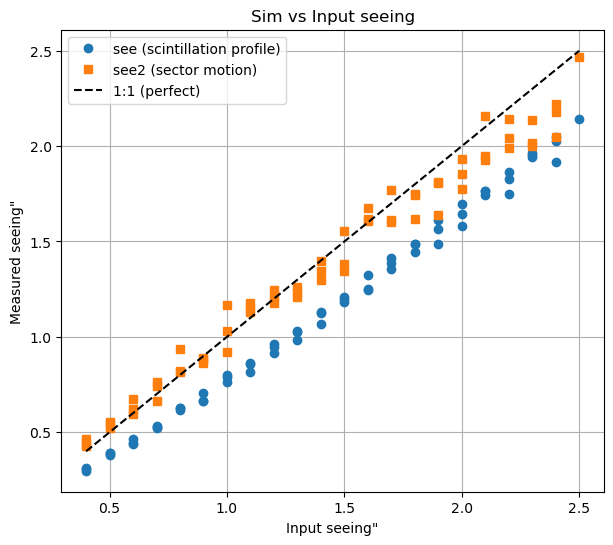

In [24]:
# Measured seeing vs. input seeing. Columns are accessed by name as
# df['col'] (a Series you can pass straight to matplotlib).
plt.figure(figsize=(7, 6))
plt.plot(df['input_seeing_arcsec'], df['see_arcsec'],  'o', label='see (scintillation profile)')
plt.plot(df['input_seeing_arcsec'], df['see2_arcsec'], 's', label='see2 (sector motion)')

lims = [df['input_seeing_arcsec'].min(), df['input_seeing_arcsec'].max()]
plt.plot(lims, lims, 'k--', label='1:1 (perfect)')

plt.xlabel('Input seeing"')
plt.ylabel('Measured seeing"')
plt.title('Sim vs Input seeing')
plt.legend()
plt.grid(True)
plt.show()


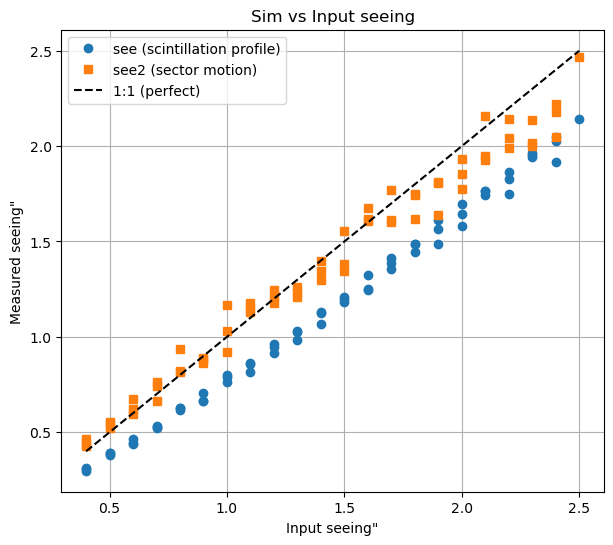

In [24]:
# Measured seeing vs. input seeing. Columns are accessed by name as
# df['col'] (a Series you can pass straight to matplotlib).
plt.figure(figsize=(7, 6))
plt.plot(df['input_seeing_arcsec'], df['see_arcsec'],  'o', label='see (scintillation profile)')
plt.plot(df['input_seeing_arcsec'], df['see2_arcsec'], 's', label='see2 (sector motion)')

lims = [df['input_seeing_arcsec'].min(), df['input_seeing_arcsec'].max()]
plt.plot(lims, lims, 'k--', label='1:1 (perfect)')

plt.xlabel('Input seeing"')
plt.ylabel('Measured seeing"')
plt.title('Sim vs Input seeing')
plt.legend()
plt.grid(True)
plt.show()


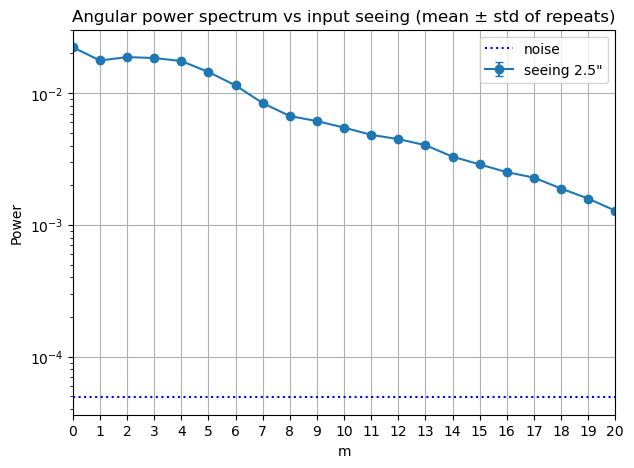

In [32]:
# Angular power spectrum (same plot as d_statmom / d_testsimul), now
# overlaying several input-seeing conditions with error bars.
# The sweep repeats each input seeing a few times, so for every seeing we
# average the repeats per angular mode m and use their spread as the error.
m = np.arange(21)                                   # angular frequency axis (0..mmax)
power_cols = [f'power_m_{j}' for j in m]

# mean and std of each power_m across the repeated runs at each input seeing
grp  = df.groupby('input_seeing_arcsec')[power_cols]
mean = grp.mean()
std  = grp.std().fillna(0.0)                        # 0 if a seeing has a single run

# pick a few seeing values spanning the range (edit as desired)
seeings = sorted(df['input_seeing_arcsec'].unique())
selected = [ seeings[-1]]

plt.figure(figsize=(7, 5))
for s in selected:
    y   = mean.loc[s].to_numpy(dtype=float)
    err = std.loc[s].to_numpy(dtype=float)
    plt.errorbar(m, np.maximum(y, 1e-12), yerr=err, marker='o', capsize=3,
                 label=f'seeing {s}\"')

# shared noise floor (mean anoise over all runs)
plt.axhline(max(float(df['anoise'].mean()), 1e-12), ls=':', color='b', label='noise')
plt.yscale('log')
plt.xlim(0, 20)
plt.xticks(np.arange(0, 21, 1))
plt.xlabel('m')
plt.ylabel('Power')
plt.title('Angular power spectrum vs input seeing (mean \u00b1 std of repeats)')
plt.legend()
plt.grid(True)
plt.show()
